In [2]:
import pandas as pd

df = pd.read_csv("../data/mwd_data.csv")

# Features (inputs)
X = df.drop(columns=["ROP (m/hr)"])

# Target (output)
y = df["ROP (m/hr)"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 3.3366421195136833
R2 Score: 0.8717941274515628


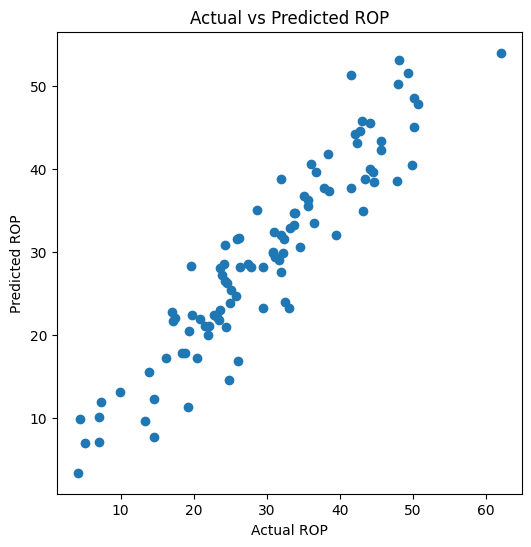

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Actual vs Predicted ROP")
plt.show()

In [8]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_
})

print(coefficients.sort_values(by="Importance", ascending=False))

                    Feature  Importance
1                WOB (klbs)    0.520139
4          Mud Weight (ppg)    0.474865
2                       RPM    0.291275
3           Flow Rate (gpm)   -0.001059
6  Standpipe Pressure (psi)   -0.002158
0                 Depth (m)   -0.009357
5             Torque (kN.m)   -0.034310
7         Inclination (deg)   -0.092919


### RPM and WOB have strong influence on ROP